# 0.Library

In [31]:
# general
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import importlib

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

# MLFlow
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

# Paths
import sys
sys.path.append('../') 
from features import data_utils as du
from features import data_pipeline as dp
from features import general_func as gf
import constants_data as cd
from features import model_utils as mu

# Reload
importlib.reload(du)
importlib.reload(dp)
importlib.reload(gf)
importlib.reload(cd)
importlib.reload(mu)

<module 'features.model_utils' from '/home/smira/myproject/detection_AD_with_VR_data/src/notebooks/../features/model_utils.py'>

# 1. Paths and Constants

In [32]:
# different experiments
experiments_list = cd.all_experiments

# Read dataframe
parent_folder = Path("../..") # go 2 folder up= "../.."
df_path = parent_folder / "data" / "produced_csv" / "2.cleaned_features_20_patients.csv"
 
df = pd.read_csv(df_path)

df.head()

,Age,Help_Rating_out_of_5,MoCA_Score,Tutorial_total_reading_time,Tutorial_max_reading_time,Tutorial_intensity_reading_time,Tutorial_total_duration_hover,Tutorial_mean_duration_hover,Tutorial_max_duration_hover,Tutorial_std_duration_hover,...,Memory_Yaw_std,Memory_Pitch_std,Memory_Roll_std,Memory_Yaw_range,Memory_dominant_hand_mean_speed,Memory_not_dominant_hand_mean_speed,Memory_dominant_hand_z_range,Memory_not_dominant_hand_y_range,Gender_Male,dominant_hand_Right
0,73.0,4,28.0,45.03,21.00,0.92,20.64,1.03,2.29,0.74,...,26.23,161.72,177.36,99.05,0.16,0.03,0.82,0.80,0,1
1,59.0,2,27.0,171.99,91.56,0.98,53.05,1.02,13.42,2.25,...,47.08,165.33,172.85,180.39,0.06,0.04,1.02,0.61,0,1
2,82.0,1,26.0,338.75,155.14,0.99,145.79,2.11,20.01,4.20,...,23.27,161.90,162.61,109.38,0.06,0.01,0.98,0.75,1,1
3,75.0,2,27.0,114.78,68.19,0.97,46.90,1.47,13.24,2.97,...,25.75,171.61,101.97,234.99,0.06,0.03,0.50,0.59,1,0
4,62.0,1,27.0,152.90,88.47,0.97,54.33,1.81,11.62,2.66,...,30.07,170.64,169.17,248.93,0.12,0.02,1.05,0.58,1,1


# 2. Data visualization

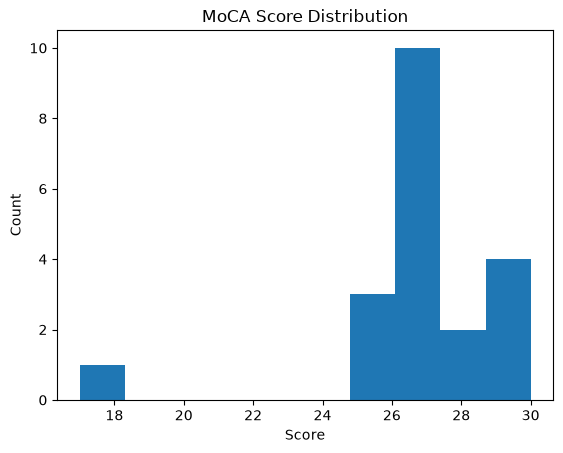

In [33]:
plt.hist(df['MoCA_Score'], bins=10)
plt.title("MoCA Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# 3. Data Splitting

In [ ]:
y = df['MoCA_Score']
df = df.drop(columns=['MoCA_Score'])
X = df

# 4. Set one : Feature selection + Train + log to MLFlow

In [38]:
import mlflow

for exp_name, models_list, k_value in experiments_list:
    
    print(f"======== Experiment: {exp_name} with k={k_value} ===========")
    mlflow.set_experiment(f"MoCA_Regression_feaute_selection_{exp_name}_{k_value}")

    for model in models_list:
        print(f"================ Run: {exp_name}_{model.__name__} =================")
        with mlflow.start_run(run_name=f"{exp_name}_{model.__name__}"):

            pipe = mu.make_model_pipeline(
                mu.make_feature_pipeline(exp_name, k_value),
                model()
            )

            scores = cross_validate(
                pipe,
                X,
                y,
                cv=5,
                scoring={
                    "r2": "r2",
                    "mae": "neg_mean_absolute_error",
                    "mse": "neg_mean_squared_error",
                    "rmse": "neg_root_mean_squared_error"
                }
            )

            # compute metrics
            r2   = scores["test_r2"].mean()
            mae  = -scores["test_mae"].mean()
            mse  = -scores["test_mse"].mean()
            rmse = -scores["test_rmse"].mean()

            # print
            print(f"Model: {model.__name__}")
            print(f"R²: {r2:.3f}")

            # MLflow logging
            mlflow.log_param("experiment", exp_name)
            mlflow.log_param("model", model.__name__)

            mlflow.log_metric("r2", r2)
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("mse", mse)
            mlflow.log_metric("rmse", rmse)

            # log model
            mlflow.sklearn.log_model(pipe, name="model", skops_trusted_types=["xgboost.sklearn.XGBRegressor", "sklearn.feature_selection._univariate_selection.f_regression"])


======== Experiment: all_features with k=0 ===========
================ Run: all_features_LinearRegression =================
Model: LinearRegression
R²: -2.847
================ Run: all_features_Ridge =================
Model: Ridge
R²: -2.734
================ Run: all_features_RandomForestRegressor =================
Model: RandomForestRegressor
R²: -0.340
================ Run: all_features_XGBRegressor =================
Model: XGBRegressor
R²: -12.596
================ Run: all_features_SVR =================
Model: SVR
R²: -0.097
================ Run: all_features_LinearSVR =================
Model: LinearSVR
R²: -117.261
================ Run: all_features_MLPRegressor =================


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Model: MLPRegressor
R²: -287.433
================ Run: all_features_Lasso =================
Model: Lasso
R²: -3.301
======== Experiment: SelectKBest with k=50 ===========
================ Run: SelectKBest_LinearRegression =================
Model: LinearRegression
R²: -8.772
================ Run: SelectKBest_Ridge =================
Model: Ridge
R²: -7.104
================ Run: SelectKBest_RandomForestRegressor =================
Model: RandomForestRegressor
R²: -0.593
================ Run: SelectKBest_XGBRegressor =================
Model: XGBRegressor
R²: -12.939
================ Run: SelectKBest_SVR =================
Model: SVR
R²: -0.198
================ Run: SelectKBest_LinearSVR =================
Model: LinearSVR
R²: -117.261
================ Run: SelectKBest_MLPRegressor =================


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum i

Model: MLPRegressor
R²: -216.495
================ Run: SelectKBest_Lasso =================
Model: Lasso
R²: -3.301


...

Model: MLPRegressor
R²: -275.755
================ Run: VarianceThreshold_Lasso =================
Model: Lasso
R²: -3.301


2026/06/26 15:18:24 INFO mlflow.tracking.fluent: Experiment with name 'MoCA_Regression_PCA_5' does not exist. Creating a new experiment.


======== Experiment: PCA with k=5 ===========
================ Run: PCA_LinearRegression =================
Model: LinearRegression
R²: -0.691
================ Run: PCA_Ridge =================
Model: Ridge
R²: -0.684
================ Run: PCA_RandomForestRegressor =================
Model: RandomForestRegressor
R²: -0.225
================ Run: PCA_XGBRegressor =================
Model: XGBRegressor
R²: -0.853
================ Run: PCA_SVR =================
Model: SVR
R²: -0.165
================ Run: PCA_LinearSVR =================
Model: LinearSVR
R²: -117.261
================ Run: PCA_MLPRegressor =================


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum i

Model: MLPRegressor
R²: -264.231
================ Run: PCA_Lasso =================
Model: Lasso
R²: -0.154


# 5. Set two : Data augmentation + Train + log to MLFlow

In [1]:
import numpy as np
import pandas as pd
# Sample tabular data
data = pd.DataFrame({'Feature1': [1.2, 2.3, 3.4, 4.5], 'Feature2': [10, 20, 30, 40]})
# Add small Gaussian noise
noise = np.random.normal(0, 0.1, data.shape)
augmented_data = data + noise
print(augmented_data)

   Feature1   Feature2
0  1.106131   9.931654
1  2.213056  20.068849
2  3.256802  30.024625
3  4.407417  40.104601


In [2]:
augmented_data = data.copy()
for col in data.columns:
    augmented_data[col] = np.random.permutation(data[col])
print(augmented_data)

   Feature1  Feature2
0       4.5        40
1       1.2        20
2       3.4        10
3       2.3        30


# 6. Set three : Best of Data augmentation and Feature selection + Train + log to MLFlow